<a href="https://colab.research.google.com/github/rracina/CB2330-portfolio/blob/main/07_exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Intertangler/CB2330-exercises/blob/main/07_measurement_error/exercise.ipynb)

# Session 07 - Measurement Error and Fitting Error

In this exercise, we will fit a power law to data corresponding to 120 cells using 3 different models of noise. The fitting pipeline is kept the same between them: i.e a curve for the mean, a score of how counts scatter around that curve, and a search for the best scoring parameters.

The data is provided in the table, plus check calls and figures.

**Deliverable:** this notebook, run, committed to `cb2330-portfolio`, with figures rendered on the published page and a line under section 6's figure saying which fit to report.

---

# Part A

The data are UMI counts for a gene in 120 cells, in molecules per cell, beside cell volumes in µm³, smallest cell first. `math` supplies $\ln x$ as `math.log`.

In [1]:
import math
import matplotlib.pyplot as plt

# cell volume, in um^3, for 120 cells, smallest first
volumes = [0.52, 0.53, 0.54, 0.54, 0.54, 0.55, 0.55, 0.55, 0.56, 0.58, 0.59, 0.59, 0.6, 0.61, 0.62,
           0.63, 0.64, 0.65, 0.71, 0.71, 0.71, 0.72, 0.73, 0.74, 0.75, 0.75, 0.75, 0.76, 0.78, 0.78,
           0.79, 0.81, 0.85, 0.86, 0.87, 0.88, 0.88, 0.91, 0.91, 0.95, 0.96, 0.98, 0.99, 1.02, 1.07,
           1.08, 1.13, 1.18, 1.2, 1.2, 1.21, 1.28, 1.29, 1.3, 1.33, 1.35, 1.35, 1.39, 1.53, 1.65,
           1.67, 1.71, 1.79, 1.82, 1.83, 1.83, 1.91, 1.96, 1.99, 2.0, 2.06, 2.07, 2.27, 2.29, 2.32,
           2.55, 2.58, 2.63, 2.65, 2.72, 2.8, 2.84, 2.92, 3.13, 3.14, 3.21, 3.23, 3.4, 3.41, 3.46,
           3.75, 3.88, 3.91, 3.96, 4.1, 4.36, 4.42, 4.44, 4.62, 4.66, 4.81, 5.12, 5.21, 5.22, 5.32,
           5.54, 5.58, 5.97, 5.99, 6.0, 6.09, 6.17, 6.54, 6.56, 6.79, 6.93, 7.53, 7.59, 7.92, 7.97]
# UMI count for 1 gene, in molecules per cell, the same 120 cells in the same order
counts = [1, 0, 0, 4, 5, 0, 4, 0, 3, 0, 0, 0, 3, 3, 3, 0, 1, 4, 1, 0, 4, 2, 0, 1, 2, 2, 2, 2, 1, 1,
          0, 1, 2, 2, 2, 2, 2, 4, 0, 0, 2, 1, 1, 3, 2, 0, 0, 5, 1, 3, 4, 3, 3, 3, 1, 1, 2, 4, 6, 5,
          9, 0, 4, 1, 5, 13, 1, 1, 14, 1, 5, 6, 14, 7, 3, 7, 7, 8, 7, 2, 4, 6, 1, 17, 5, 11, 2, 5, 4, 7,
          7, 8, 3, 10, 1, 11, 12, 5, 1, 14, 17, 12, 11, 3, 19, 6, 2, 15, 2, 9, 1, 11, 43, 9, 2, 24, 27, 22, 13, 4]
N = len(counts)                                   # cells
print(N, "cells, volumes", volumes[0], "to", volumes[N - 1], "um^3")


120 cells, volumes 0.52 to 7.97 um^3


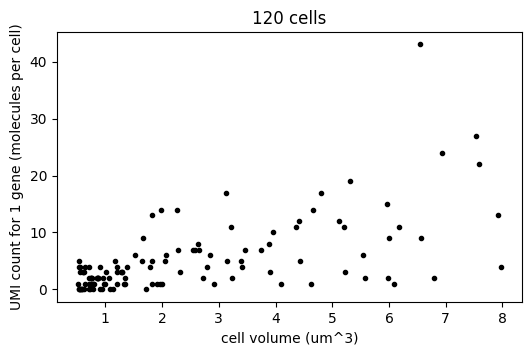

In [2]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(volumes, counts, marker="o", markersize=3, linestyle="none", color="black")
ax.set_xlabel("cell volume (um^3)")
ax.set_ylabel("UMI count for 1 gene (molecules per cell)")
ax.set_title("120 cells")
plt.show()


Below is the table, 4 bands or quantiles of 30 cells, with mean, variance and cells with 0 counts per quantile.

In [3]:
# the table: 4 bands of 30 cells, smallest volumes first
print("volume band (um^3)   mean count   variance   cells scoring 0")
for k in range(4):
    mean_k = 0.0
    zeros_k = 0
    for i in range(30 * k, 30 * k + 30):
        mean_k = mean_k + counts[i] / 30
        if counts[i] == 0:
            zeros_k = zeros_k + 1
    variance_k = 0.0
    for i in range(30 * k, 30 * k + 30):
        variance_k = variance_k + (counts[i] - mean_k) ** 2 / 29      # divided by 29, not 30
    print(volumes[30 * k], "to", volumes[30 * k + 29], "       ", round(mean_k, 2), "       ", round(variance_k, 2), "     ", zeros_k)


volume band (um^3)   mean count   variance   cells scoring 0
0.52 to 0.78         1.63         2.45       10
0.79 to 1.65         2.17         2.63       5
1.67 to 3.46         5.9         19.27       1
3.75 to 7.97         10.8         86.72       0


## 1. Curve

Each fit involves a curve representing the mean and a noise model.
A power law is proposed, where $\kappa$ is the mean count of a 1 µm³ cell and $b$ sets how counts scale with volume, with $b = 1$ for a cell whose mRNA keeps pace with its volume.

$$\mu(x) = \kappa\, x^{b}$$

`mean_count` takes a volume and a candidate $\kappa$ and $b$, and returns a mean count in molecules per cell. The check cell tests for $\kappa$ at 1 µm³ and for a straight line at $b = 1$.

**Fill the gap to write the curve.** `mean_count` receives `x`, `kappa` and `b`, and returns `kappa` times `x` to the power `b`, where a power is `**`.

In [5]:
def mean_count(x, kappa, b):
    """mu(x) = kappa x^b  the mean count, in molecules per cell, at volume x."""
    # ⭐⭐⭐ Your code here ⭐⭐⭐
    return kappa*x**b


In [6]:
assert mean_count(1.0, 2.31, 0.918) == 2.31, "at 1 um^3 the mean count is kappa"
assert abs(mean_count(4.0, 2.0, 0.5) - 4.0) < 1e-12, "2 times the square root of 4"
assert abs(mean_count(8.0, 1.8, 1.0) - 14.4) < 1e-12, "b = 1 is a straight line through 0"
print("ok  mean count at 4 um^3 with kappa = 2.31, b = 0.918:", round(mean_count(4.0, 2.31, 0.918), 2), "molecules per cell")


ok  mean count at 4 um^3 with kappa = 2.31, b = 0.918: 8.25 molecules per cell


## 2. Least squares

Least squares is a Gaussian noise model in which we are allowed to ignore the constant terms:
eg taking a normal's negative log-likelihood apart leaves $S$ as the term carrying $\theta$.
So minimising $S$ assumes counts scatter symmetrically around the curve,
with a constant $\sigma$ across volumes.
We will write $S$ as a loop over cells, a residual per cell, squared and added up.

$$S(\kappa, b) = \sum_{i=1}^{N} \bigl(y_i - \kappa\, x_i^{b}\bigr)^2$$

`sum_squares` takes a candidate $\kappa$ and $b$ and returns a sum over cells, in molecules². It reads `volumes` and `counts` from the data cell instead of receiving them. The check cell tests 2 cells by hand, then $S(2, 1)$, then a lower score at $(2.26, 0.932)$.

**Fill the gap to write the score.** `total` is set up at 0 and returned. Write a loop over `range(N)` that takes cell `i`'s residual, `counts[i]` minus `mean_count(volumes[i], kappa, b)`, and adds its square to `total`.

In [8]:
def sum_squares(kappa, b):
    """S(kappa, b) = the sum over cells of (y_i - kappa x_i^b)^2, in molecules^2."""
    total = 0.0
    # ⭐⭐⭐ Your code here ⭐⭐⭐
    for i in range(N):
      total = total + ((counts[i] - mean_count(volumes[i], kappa, b))**2)

    return total


In [9]:
by_hand = (counts[0] - 2.0 * volumes[0]) ** 2 + (counts[1] - 2.0 * volumes[1]) ** 2
first_two = 0.0
for i in range(2):
    first_two = first_two + (counts[i] - mean_count(volumes[i], 2.0, 1.0)) ** 2
assert abs(first_two - by_hand) < 1e-12
assert abs(sum_squares(2.0, 1.0) - 2953.8368) < 0.001, "S at kappa = 2, b = 1"
assert sum_squares(2.26, 0.932) < sum_squares(2.0, 1.0), "(2.26, 0.932) scores lower"
print("ok  S(2, 1) =", round(sum_squares(2.0, 1.0), 1), "molecules^2;  S(2.26, 0.932) =", round(sum_squares(2.26, 0.932), 1))


ok  S(2, 1) = 2953.8 molecules^2;  S(2.26, 0.932) = 2946.8


## 3. Fit

Here we search a grid: `fit` receives a score as an argument.
A grid is slow, but the advantage with a grid is that it won't stop in a local minimum the way a walk can.

$$(\hat{\kappa}, \hat{b}) = \arg\min_{\kappa,\,b} S(\kappa, b)$$

`kappa_candidates` holds 56 values from 1.50 to 2.60 and `b_candidates` holds 61 from 0.800 to 1.040, so a loop can run over values directly. `fit` takes a score, a function of $\kappa$ and $b$, and returns the lowest-scoring pair as a list `[kappa_hat, b_hat]`. The check cell tests `fit` on a score whose minimum is known before anything runs, and then against 2.26 and 0.932.

**Fill the gap to write the search.** `best` and `best_pair` are set up from a first pair of candidates, and `best_pair` is returned. Write a loop over `kappa_candidates` with a loop over `b_candidates` inside it, score a pair with `score(kappa, b)`, and when that score is below `best`, store it in `best` and store `[kappa, b]` in `best_pair`.

In [10]:
kappa_candidates = [0.0] * 56
for j in range(56):
    kappa_candidates[j] = round(1.5 + 0.02 * j, 2)      # 1.50 to 2.60 molecules per cell at 1 um^3
b_candidates = [0.0] * 61
for j in range(61):
    b_candidates[j] = round(0.80 + 0.004 * j, 3)        # 0.800 to 1.040, dimensionless


def fit(score):
    """The pair (kappa, b) on the grid with the lowest score, as a list [kappa_hat, b_hat]."""
    best = score(kappa_candidates[0], b_candidates[0])
    best_pair = [kappa_candidates[0], b_candidates[0]]
    # ⭐⭐⭐ Your code here ⭐⭐⭐
    for j in kappa_candidates:
      for b in b_candidates:
        s = score(j,b)
        if s < best:
          best = s
          best_pair = [j, b]

    return best_pair


fit_squares = fit(sum_squares)


In [11]:
def bowl(kappa, b):
    return (kappa - 2.0) ** 2 + (b - 1.0) ** 2
assert fit(bowl) == [2.0, 1.0], "a score whose minimum is known before anything runs"
assert abs(fit_squares[0] - 2.26) <= 0.02 and abs(fit_squares[1] - 0.932) <= 0.004, "2.26 and 0.932, to a grid step"
print("ok  least squares on the counts:    kappa =", fit_squares[0], " b =", fit_squares[1], "  (expected: 2.26, 0.932)")


ok  least squares on the counts:    kappa = 2.26  b = 0.932   (expected: 2.26, 0.932)


## 4. Least squares on logs

Taking logs is a common solution to handle scatter growing with the mean, and 16 of these cells had a count of 0 molecules, where $\ln 0$ is undefined. Using $\ln(1 + y)$ avoids that at a cost - namely that a step from 0 to 1 molecule moves $\ln(1 + y)$ by 0.69 and a step from 10 to 11 moves it by 0.09, so small cells dominate $S_{\log}$. We will see $\hat{\kappa}$ drop from 2.26 to 1.76.

$$S_{\log}(\kappa, b) = \sum_{i=1}^{N} \bigl(\ln(1 + y_i) - \ln(1 + \kappa\, x_i^{b})\bigr)^2$$

`sum_squares_log` takes the same arguments as `sum_squares`, and `fit` runs on it unchanged. The check cell tests $S_{\log}(2, 1)$, then a fit of 1.76 and 0.912.

**Fill the gap to write the score on logs.** `return total` is given and the body above it is blank, `total = 0.0` included. It's section 2's loop with count and curve mean passed through `math.log(1 + ...)` before they're subtracted.

In [15]:
def sum_squares_log(kappa, b):
    """S_log(kappa, b) = the sum over cells of (ln(1 + y_i) - ln(1 + kappa x_i^b))^2."""
    # ⭐⭐⭐ Your code here ⭐⭐⭐
    total = 0.0
    for i in range(N):
      total = total + ((math.log(1 + counts[i]) - math.log(1 + mean_count(volumes[i],kappa,b)))**2)

    return total


fit_log = fit(sum_squares_log)


In [16]:
assert abs(sum_squares_log(2.0, 1.0) - 57.2938) < 0.001, "S_log at kappa = 2, b = 1"
assert abs(fit_log[0] - 1.76) <= 0.02 and abs(fit_log[1] - 0.912) <= 0.004, "1.76 and 0.912, to a grid step"
print("ok  least squares on log(1 + y):    kappa =", fit_log[0], " b =", fit_log[1], "  (expected: 1.76, 0.912)")


ok  least squares on log(1 + y):    kappa = 1.76  b = 0.912   (expected: 1.76, 0.912)


## 5. Count model

We will try a negative binomial here in place of a normal, while the curve, sum of logs and search stay as they were.
A negative binomial's variance is $\mu + \mu^{2}/c$, so spread grows with the mean as in the table, and probability does not extend below 0 molecules, however it costs us a third parameter $c$ to estimate.

$$p(y \mid \mu, c) = \binom{y + c - 1}{c - 1}\, p^{c}\, (1 - p)^{y}, \quad p = \frac{c}{c + \mu}, \qquad \mathrm{NLL}(\kappa, b, c) = -\sum_{i=1}^{N} \ln p\bigl(y_i \mid \kappa\, x_i^{b},\, c\bigr)$$

`neg_binomial` is written. It's a negative binomial with $y$ counting trials that weren't successes, so trials number $y + c$, and $p$ is chosen to make $\mu$ the mean. `math.comb(n, k)` counts ways of choosing `k` things out of `n`, and it takes whole numbers, so $c$ is a whole number of successes here. `nll_counts` takes a candidate $\kappa$, $b$ and $c$ and returns a sum over cells. The check cell tests for probabilities summing to 1, for a mean of $\mu$, and $\mathrm{NLL}(2, 1, 2)$.

**Fill the gap to write the negative log-likelihood.** `return total` is given and the body above it is blank. It's a loop over `range(N)`: cell `i`'s mean is `mean_count(volumes[i], kappa, b)`, the probability of `counts[i]` at that mean is `neg_binomial(counts[i], mu, c)`, and `math.log` of that probability is subtracted from `total`.

In [37]:
def neg_binomial(y, mu, c):
    """p(y | mu, c)  the probability of y molecules in a cell whose mean count is mu, with c successes required, c a whole number."""
    p = c / (c + mu)                              # the probability of a success, chosen so that the mean is mu
    ways = math.comb(y + c - 1, y)                # (y + c - 1) choose y, the same number as (y + c - 1) choose (c - 1)
    return ways * p ** c * (1 - p) ** y


def nll_counts(kappa, b, c):
    """NLL(kappa, b, c) = - the sum over cells of ln p(y_i | kappa x_i^b, c)."""
    # ⭐⭐⭐ Your code here ⭐⭐⭐
    total = 0.0
    for i in range(N):
        mu = mean_count(volumes[i], kappa, b)
        total = total - math.log(neg_binomial(int(counts[i]), mu, int(c)))

    return total


In [38]:
mass = 0.0
mean_check = 0.0
for y in range(400):
    mass = mass + neg_binomial(y, 5.0, 2)
    mean_check = mean_check + y * neg_binomial(y, 5.0, 2)
assert abs(mass - 1.0) < 1e-9, "probabilities sum to 1 over counts"
assert abs(mean_check - 5.0) < 1e-6, "and the mean is mu"
assert abs(neg_binomial(0, 5.0, 2) - (2.0 / 7.0) ** 2) < 1e-12, "no molecules: c successes in a row"
assert abs(nll_counts(2.0, 1.0, 2) - 290.985) < 0.01, "NLL at kappa = 2, b = 1, c = 2"
assert nll_counts(2.31, 0.918, 2) < nll_counts(2.0, 1.0, 2), "(2.31, 0.918) scores lower"
print("ok  NLL(2, 1, 2) =", round(nll_counts(2.0, 1.0, 2), 2), ";  NLL(2.31, 0.918, 2) =", round(nll_counts(2.31, 0.918, 2), 2))


ok  NLL(2, 1, 2) = 290.98 ;  NLL(2.31, 0.918, 2) = 290.13


The grid with a loop over $c$ 30,744 candidates.

In [39]:
# the grid of section 3 with a loop over c around it
c_candidates = [0] * 9
for j in range(9):
    c_candidates[j] = 1 + j                       # 1 to 9 successes, whole numbers for math.comb

best = nll_counts(kappa_candidates[0], b_candidates[0], c_candidates[0])
fit_counts = [kappa_candidates[0], b_candidates[0], c_candidates[0]]
for c in c_candidates:
    for kappa in kappa_candidates:
        for b in b_candidates:
            s = nll_counts(kappa, b, c)
            if s < best:
                best = s
                fit_counts = [kappa, b, c]


In [40]:
assert abs(fit_counts[0] - 2.31) <= 0.02 and abs(fit_counts[1] - 0.918) <= 0.004 and fit_counts[2] == 2
print("ok  maximum likelihood, count model: kappa =", fit_counts[0], " b =", fit_counts[1], " c =", fit_counts[2], "  (expected to a grid step: 2.31, 0.918, 2)")


ok  maximum likelihood, count model: kappa = 2.32  b = 0.916  c = 2   (expected to a grid step: 2.31, 0.918, 2)


## 6. Comparison

These curves differ little in their means whereas their noise models differ a lot.
Least squares assumes a band of constant width, and a normal puts 68% of cells within $1\sigma$ of the curve for small cells and large alike, which is a prediction we can count against these cells.

$$\hat{\sigma} = \sqrt{S(\hat{\kappa}, \hat{b}) / N}$$

$\hat{\sigma}$ is the residuals' standard deviation around the least-squares curve, in molecules per cell, the $\sigma$ a normal needs to account for them. This cell prints the fits and draws their curves on the data, with a band drawn $2\hat{\sigma}$ either side of the least-squares curve. The check cell counts cells within $1\hat{\sigma}$ of that curve per band of 30, against 68% of 30, about 20.

**Under the figure, say in a line which fit to report, and what band and counts per band say about least squares.**

fit                           kappa    b
least squares on the counts   2.26    0.932
least squares on log(1 + y)   1.76    0.912
maximum likelihood, counts    2.32    0.916    c = 2
sigma assumed by least squares: 4.96 molecules per cell, at every volume


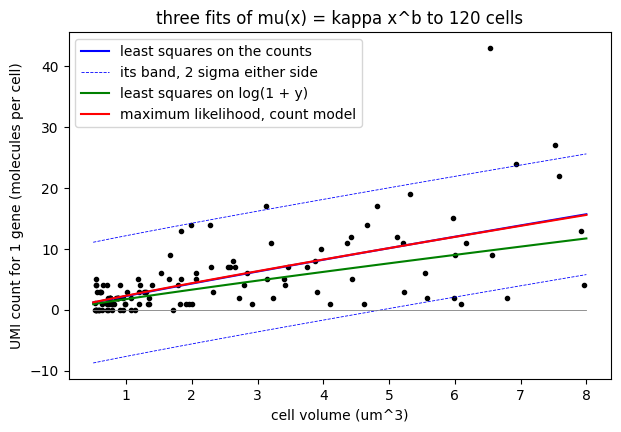

⭐⭐⭐ The best fit is the custom one (max likelihood), as the least squares on the counts 
 may not represent the counts below zero, and the least squares on the log(1 + y) 
 implements adding one in the logarithm that misrepresents the actual values⭐⭐⭐


In [47]:
print("fit                           kappa    b")
print("least squares on the counts  ", fit_squares[0], "  ", fit_squares[1])
print("least squares on log(1 + y)  ", fit_log[0], "  ", fit_log[1])
print("maximum likelihood, counts   ", fit_counts[0], "  ", fit_counts[1], "   c =", fit_counts[2])

sigma_hat = (sum_squares(fit_squares[0], fit_squares[1]) / N) ** 0.5      # the sigma least squares assumes, molecules per cell
print("sigma assumed by least squares:", round(sigma_hat, 2), "molecules per cell, at every volume")

view = [0.0] * 76
curve_squares = [0.0] * 76
curve_log = [0.0] * 76
curve_counts = [0.0] * 76
band_low = [0.0] * 76
band_high = [0.0] * 76
for j in range(76):
    view[j] = 0.5 + 0.1 * j                       # 0.5 to 8.0 um^3
    curve_squares[j] = mean_count(view[j], fit_squares[0], fit_squares[1])
    curve_log[j] = mean_count(view[j], fit_log[0], fit_log[1])
    curve_counts[j] = mean_count(view[j], fit_counts[0], fit_counts[1])
    band_low[j] = curve_squares[j] - 2 * sigma_hat
    band_high[j] = curve_squares[j] + 2 * sigma_hat
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(volumes, counts, marker="o", markersize=3, linestyle="none", color="black")
ax.plot(view, curve_squares, color="blue", label="least squares on the counts")
ax.plot(view, band_low, color="blue", linewidth=0.6, linestyle="dashed", label="its band, 2 sigma either side")
ax.plot(view, band_high, color="blue", linewidth=0.6, linestyle="dashed")
ax.plot(view, curve_log, color="green", label="least squares on log(1 + y)")
ax.plot(view, curve_counts, color="red", label="maximum likelihood, count model")
ax.plot([0.5, 8.0], [0.0, 0.0], color="grey", linewidth=0.6)
ax.set_xlabel("cell volume (um^3)")
ax.set_ylabel("UMI count for 1 gene (molecules per cell)")
ax.set_title("three fits of mu(x) = kappa x^b to 120 cells")
ax.legend()
plt.show()

print("⭐⭐⭐ The best fit is the custom one (max likelihood), as the least squares on the counts \n may not represent the counts below zero, and the least squares on the log(1 + y) \n implements adding one in the logarithm that misrepresents the actual values⭐⭐⭐")

In [48]:
inside = [0] * 4                                  # cells within 1 sigma of the least-squares curve, per band of 30
for k in range(4):
    for i in range(30 * k, 30 * k + 30):
        centre = mean_count(volumes[i], fit_squares[0], fit_squares[1])
        if abs(counts[i] - centre) < sigma_hat:
            inside[k] = inside[k] + 1
assert band_low[0] < 0, "the band of least squares reaches below 0 molecules"
assert inside[0] == 30 and inside[3] < 20, "too wide for the small cells, too narrow for the large ones"
print("ok  the 2 sigma band of least squares starts at", round(band_low[0], 1), "molecules per cell at 0.5 um^3")
print("    cells within 1 sigma of its curve, per band of 30:", inside, " against 68% of 30, about 20")


ok  the 2 sigma band of least squares starts at -8.7 molecules per cell at 0.5 um^3
    cells within 1 sigma of its curve, per band of 30: [30, 30, 24, 14]  against 68% of 30, about 20


---

# Part B

Part B swaps the noise model again, and tests a fit against parameters that are known.

Part B is optional and done outside the session, and a route is enough.

- **A Poisson as the count model.** Below, already written: section 5 with a Poisson in place of a negative binomial. It returns the same $\hat{\kappa}$ and $\hat{b}$ at an NLL 66 higher, because a Poisson has variance equal to mean and the table doesn't.
- **A recovery test.** I generated these counts from $\kappa = 1.8$, $b = 1$ and $c = 2$, and I haven't said so until now. No fit above returns 1.8 from 120 cells. Fresh counts drawn from those parameters a few hundred times, with a fit per set, show how far an estimate scatters from 1.8 and 1: in my run $\hat{b}$ from least squares scattered about 2.5 times wider than $\hat{b}$ from the count model. `numpy.random.default_rng().negative_binomial(c, c / (c + mu))` draws a count.
- **A walk instead of a grid.** Gradient descent on `nll_counts` with $c$ held at 2, and a slope for $\kappa$ and for $b$, against 30,744 scores here.
- **Hand it to a library.** `scipy.optimize.minimize` on these scores, with $c$ held at 2 for the count model, returns $\hat{\kappa}$ and $\hat{b}$ to more digits than a grid step of 0.02 can. A $c$ of 2.36 sits between whole numbers, which `math.comb` doesn't take.
- **The table against the model.** A negative binomial's variance is $\mu + \mu^{2}/c$. At the fitted $c$, that variance per band can be set beside the table's 2.45, 2.63, 19.27 and 86.72.

## B1. Poisson count model

$$p(y \mid \mu) = \frac{\mu^{y} e^{-\mu}}{y!}, \qquad \mathrm{NLL}(\kappa, b) = -\sum_{i=1}^{N} \ln p\bigl(y_i \mid \kappa\, x_i^{b}\bigr)$$

`factorial` and `poisson` are written. `nll_poisson` takes $\kappa$ and $b$, and `fit` runs on it unchanged. The check cell compares NLL at Poisson and negative binomial estimates.

In [ ]:
def factorial(x):
    """x! as a product, 0! = 1."""
    total = 1
    for k in range(1, x + 1):
        total = total * k
    return total


def poisson(x, theta):
    """p(x | theta) = theta^x e^(-theta) / x!"""
    return theta ** x * math.exp(-theta) / factorial(x)


def nll_poisson(kappa, b):
    """NLL(kappa, b) = - the sum over cells of ln p(y_i | kappa x_i^b), a Poisson per cell."""
    total = 0.0
    for i in range(N):
        total = total - math.log(poisson(counts[i], mean_count(volumes[i], kappa, b)))
    return total


fit_poisson = fit(nll_poisson)


In [ ]:
nll_at_poisson = nll_poisson(fit_poisson[0], fit_poisson[1])
nll_at_counts = nll_counts(fit_counts[0], fit_counts[1], fit_counts[2])
assert nll_at_counts < nll_at_poisson - 50, "the negative binomial scores far lower on the same cells"
print("ok  Poisson:           kappa =", fit_poisson[0], " b =", fit_poisson[1], " NLL =", round(nll_at_poisson, 1))
print("    negative binomial: kappa =", fit_counts[0], " b =", fit_counts[1], " c =", fit_counts[2], " NLL =", round(nll_at_counts, 1))
